# SKKU 2024 Challenge
## Quantum State Tomography

In [1]:
import numpy as np
import qiskit
from qiskit_aer import Aer

In [120]:
## utils.py
backend = Aer.get_backend("aer_simulator")
def create_1q_target_circuit(qc_data):
    qc = qiskit.QuantumCircuit(1)
    qc.ry(qc_data[0],0)
    qc.rz(qc_data[1],0)
    return qc

def create_2q_target_circuit(qc_data):
    qc = qiskit.QuantumCircuit(2)
    for i in range(2):
        qc.ry(qc_data[2*i],i)
        qc.rz(qc_data[2*i+1],i)
    qc.cx(0,1)
    qc.rz(qc_data[4],1)
    qc.cx(0,1)
    for i in range(2):
        qc.ry(qc_data[2*i+5],i)
        qc.rz(qc_data[2*i+6],i)
    return qc

backend2 = Aer.get_backend("statevector_simulator")
def give_score(U_hidden, U_gen):
    qc = U_hidden.compose(U_gen.inverse())
    result = backend2.run(qc).result()
    score = result.get_statevector()[0]
    return np.abs(score)

## TODO : make error handler
def MeasurementResultHandler(result:dict, num_qubits:int, num_shots:int=100):
	for i in range(2**num_qubits):
		result[format(i,"#x")] = np.array(result[format(i,"#x")]/num_shots) if result.get(format(i,"#x")) else np.array(0)
	return result
   

def generate_clifford_circ(num_qubits, depth):
    U_hidden = qiskit.QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        U_hidden.h(i)
    count = 0
    s1s2 = {-1,-1}
    while(count < depth):
        site_i = int(np.random.rand()*num_qubits)
        site_j = int(np.random.rand()*num_qubits)
        if(site_i == site_j or {site_i, site_j} == s1s2):
            continue
        print(site_i, site_j, count)
        count += 1
        s1s2 = {site_i, site_j}
        U_hidden.cz(site_i, site_j)
    return U_hidden

def low_depth(num_qubits):
    qc = qiskit.QuantumCircuit(num_qubits)
    for i in range(0, num_qubits-1, 2):
        params = np.random.rand(15)*2*np.pi
        qc.u(params[0], params[1], params[2],i)
        qc.u(params[3], params[4], params[5],i+1)
        qc.rxx(params[6],i,i+1)
        qc.ryy(params[7],i,i+1)
        qc.rzz(params[8],i,i+1)
        qc.u(params[9], params[10], params[11],i)
        qc.u(params[12], params[13], params[14],i+1)
        
    for j in range(1,num_qubits - (num_qubits +1)%2 ,2):
        params = np.random.rand(15)*2*np.pi
        qc.u(params[0], params[1], params[2],j)
        qc.u(params[3], params[4], params[5],j+1)
        qc.rxx(params[6],j,j+1)
        qc.ryy(params[7],j,j+1)
        qc.rzz(params[8],j,j+1)
        qc.u(params[9], params[10], params[11],j)
        qc.u(params[12], params[13], params[14],j+1)
    
    U_hidden = qc
    return U_hidden

### Problem 1

#### Part I

##### a)

In a given single qubit pure state can be written as:
$$
\ket{\psi} = a\ket{0} + b e^{i\theta} \ket{1}
$$
where $a, b, \theta$ are real parameter subject to $a^2 + b^2 =1$ and $0 \leq \theta < 2\pi$. 
In order to determine these three parameter, it requires at least three measurement. 

Our measurement is performed via POVM. There are detectors whose number is equal to the number of qubits. 
In this scenerio, we perform $z$-basis projection measurement. Therefore, the POVM becomes $\left\{ \ket{0}\bra{0}, \ket{1}\bra{1}\right\}$, each corresponds to the presense of signal or not. 
Let $\hat{m}_0, \hat{m}_1$ denote the estimated probability of occuring signals. 
We can add another operation $U$ before the measurement and after the computational stage(here, state preparation), we can perform measurement another POVM basis, $\left\{ U^{\dagger} \ket{0}\bra{0} U, U^{\dagger} \ket{1}\bra{1} U\right\}$.

In first measurement, to determine $a, b$, we can directly perform measurement without any unitary operation. That is $U^1 = I$, here. 
Then, we see:
$$
\begin{align}
	\hat{m}_0 &\simeq  \left| \bra{\psi}\ket{0} \right|^2 &= a^2 \\
	\hat{m}_1 &\simeq  \left| \bra{\psi}\ket{1} \right|^2 &= b^2 \\
\end{align}
$$
Therefore, we can estimate,
$$
\begin{align}
	a &= \sqrt{\hat{m}_0} \\
	b &= \sqrt{\hat{m}_1} \\
\end{align}
$$
On the other hand, we need two additional measurement. 
Here let $U_2 = H$, where $H$ is a hadamard gate.
$$
H = \frac{1}{\sqrt{2}}
\begin{pmatrix}
	1 & 1 \\
	1 & -1
\end{pmatrix}.
$$
Then, our POVM becomes $\left\{ \ket{+}\bra{+}, \ket{-}\bra{-}\right\}$ where $\ket{+}, \ket{-}$ are the eigenstate of Pauli-X matrix whose eigenvalue is $1,-1$ for each.
Here, let $\hat{m}_{+}, \hat{m}_{-}$ be the estimated probability of occuring signals.
$$
\begin{align}
	\hat{m}_{+} &\simeq  \left| \bra{\psi}\ket{+} \right|^2 &= \left| \frac{a + b e^{i\theta}}{2} \right|^2 &= \frac{1 + 2ab\cos\theta}{2}  \\
	\hat{m}_{-} &\simeq  \left| \bra{\psi}\ket{-} \right|^2 &= \left| \frac{a - b e^{i\theta}}{2} \right|^2 &= \frac{1 - 2ab\cos\theta}{2} 
\end{align}
$$
Or,
$$
\cos\theta = \frac{\hat{m}_{+} - \hat{m}_{-}}{2ab}
$$
Here, it is not enough yet. As there is a degree of freedom choosing a sign of $\sin\theta$. 
Finally, let $U_3 = S H$ where $S$ is S gate.
$$
S = \begin{pmatrix}
	1 & 0 \\
	0 & i 
\end{pmatrix}.
$$
Then our POVM becomes $\left\{ \ket{i}\bra{i}, \ket{-i}\bra{-i}\right\}$ where $\ket{i}, \ket{-i}$ are the eigenstate of Pauli-Y matrix whose eigenvalue is $1,-1$ for each.
Here, let $\hat{m}_{i}, \hat{m}_{-i}$ be the estimated probability of occuring signals.
$$
\begin{align}
	\hat{m}_{i} &\simeq  \left| \bra{\psi}\ket{i} \right|^2 &= \left| \frac{a + b e^{i(\theta + \frac{\pi}{2})}}{2} \right|^2 &= \frac{1 + 2ab\sin\theta}{2}  \\
	\hat{m}_{-i} &\simeq  \left| \bra{\psi}\ket{-i} \right|^2 &= \left| \frac{a - b e^{i\theta  + \frac{\pi}{2}}}{2} \right|^2 &= \frac{1 - 2ab\sin\theta}{2}  
\end{align}
$$
Or,
$$
\sin\theta = \frac{\hat{m}_{i} - \hat{m}_{-i}}{2ab}
$$

##### b)

Now, Let me explain how we reconstruct circuit parameter. 
In glance of action of $RY$ and $RZ$ gate, we see:
$$
RY(\phi_{y}) = 
\begin{pmatrix}
	\cos \frac{\phi_{y}}{2} & -\sin \frac{\phi_{y}}{2} \\
	\sin \frac{\phi_{y}}{2} & \cos \frac{\phi_{y}}{2}
\end{pmatrix}
$$
and 
$$
RZ(\phi_{z}) = 
\begin{pmatrix}
	1 & 0 \\
	0 & e^{i\phi_{z}}
\end{pmatrix}
$$
Therefore, we have:
$$
RZ(\phi_{z})RY(\phi_{y}) = \cos \frac{\phi_{y}}{2} \ket{0} + e^{i\phi_{z}} \sin \frac{\phi_{y}}{2} \ket{1} .
$$
Comparing this equation to the first given $\ket{\psi}$, we find $\phi_{y} = 2\arccos a$ with $\phi_{y} = 2\arcsin b$ and $\phi_{z} = \theta$.

In [233]:
def SingleQubitQST(U_hidden, num_shots:int=100):
	hidden_circuit = U_hidden.copy()
	
	qc1 = qiskit.QuantumCircuit(1)
	circ1 = hidden_circuit.compose(qc1)
	circ1.measure_all()
	#print(circ1.draw())
	
	qc2 = qiskit.QuantumCircuit(1)
	qc2.h(0)
	circ2 = hidden_circuit.compose(qc2)
	circ2.measure_all()
	#print(circ2.draw())
	
	qc3 = qiskit.QuantumCircuit(1)
	qc3.s(0)
	qc3.h(0)
	circ3 = hidden_circuit.compose(qc3)
	circ3.measure_all()
	#print(circ3.draw())
	
	result1 = MeasurementResultHandler(backend.run(circ1, shots=num_shots).result().data()["counts"], 1, num_shots)
	result2 = MeasurementResultHandler(backend.run(circ2, shots=num_shots).result().data()["counts"], 1, num_shots)
	result3 = MeasurementResultHandler(backend.run(circ3, shots=num_shots).result().data()["counts"], 1, num_shots)

	m0 = result1.get("0x0"); m1 = result1.get("0x1")
	phi = np.arctan2(np.sqrt(m1), np.sqrt(m0))
	phi = phi if phi > 0 else phi + 2*np.pi
	statevector = np.array([np.cos(phi), np.sin(phi)], dtype=np.complex64)

	#print(np.cos(phi), np.sin(phi), np.cos(phi)**2, np.sin(phi)**2, m0, m1)

	m_p = result2.get("0x0"); m_m = result2.get("0x1")
	cos = (m_p - m_m)/(2*np.cos(phi)*np.sin(phi))
 
	m_pi = result3.get("0x0"); m_mi = result3.get("0x1")
	sin = (-m_pi + m_mi)/(2*np.cos(phi)*np.sin(phi))

	temp = np.array([cos, sin])

	cos = cos / np.linalg.norm(temp)
	sin = sin / np.linalg.norm(temp)
	print(circ1.draw())
	theta = np.arctan2(sin, cos)
	theta = theta if theta > 0 else theta + 2*np.pi
 
	statevector[1] *= np.exp(1j*theta)
	circuit_parameter = np.array([2*phi, theta])

	return statevector, circuit_parameter

def SingleQubitCircuit(statevector):
	cos = np.linalg.norm(statevector[0]); sin = np.linalg.norm(statevector[1])
	phi = np.arctan2(sin,cos)
	theta = (np.log(statevector[1]/np.linalg.norm(statevector[1]))*-1j).real
 
	U_gen = qiskit.QuantumCircuit(1)
	U_gen.ry(2*phi,0)
	U_gen.rz(theta,0)
 
	return U_gen

In [729]:
random_vec = np.random.rand(2)*2*np.pi
U_hidden = create_1q_target_circuit(random_vec)
statevector, circuit_parameter = SingleQubitQST(U_hidden)
U_gen = SingleQubitCircuit(statevector)
#print(circuit_parameter)
give_score(U_hidden, U_gen)

        ┌────────────┐┌────────────┐ ░ ┌─┐
     q: ┤ Ry(6.1308) ├┤ Rz(4.2403) ├─░─┤M├
        └────────────┘└────────────┘ ░ └╥┘
meas: 1/════════════════════════════════╩═
                                        0 


np.float64(0.9970977642943546)

#### Part II

##### a)

In a given single qubit pure state can be written as:
$$
\ket{\psi} = a\ket{00} + b \ket{01} + c \ket{10} + d\ket{11}
$$
where $a$ is a real posivive number $b, c$ and $d$ are complex numbers subject to $a^2 + b^2 + c^2 + d^2 =1$ without loss of generality.
If the parameters are subjected to real numbers, it seems sufficient to idenify all the parameters $a, b, c$ and $d$ with running two circuits. 
First, we run circuit without any additional operation, $U=I$. 
Then our POVM bases are $\left\{ \ket{00}\bra{00}, \ket{01}\bra{01}, \ket{10}\bra{10}, \ket{11}\bra{11} \right\}$, which directly reproduce $a^2 , b^2 , c^2$ and $d^2$.
That is,
$$
\begin{align}
	\hat{m}_{00} &\simeq \left| \bra{\psi}\ket{00} \right|^2 &= a^2 \\ 
	\hat{m}_{01} &\simeq \left| \bra{\psi}\ket{01} \right|^2 &= b^2 \\ 
	\hat{m}_{10} &\simeq \left| \bra{\psi}\ket{10} \right|^2 &= c^2 \\ 
	\hat{m}_{11} &\simeq \left| \bra{\psi}\ket{11} \right|^2 &= d^2  
\end{align}
$$
where $\hat{m}_{00}, \hat{m}_{01}, \hat{m}_{10}, \hat{m}_{11}$ are the estimated probability from the measurement outcome, $\left\{ \ket{00}\bra{00}, \ket{01}\bra{01}, \ket{10}\bra{10}, \ket{11}\bra{11} \right\}$.
Next, we can add Hadamard operation both qubits, then the resulting POVM basis are $\left\{ \ket{++}\bra{++}, \ket{+-}\bra{+-}, \ket{-+}\bra{-+}, \ket{--}\bra{--} \right\}$.
Then, 
$$
\begin{align}
	\hat{m}_{++} &\simeq \left| \bra{\psi}\ket{++} \right|^2 &= \frac{(a+b+c+d)^2}{4} \\ 
	\hat{m}_{+-} &\simeq \left| \bra{\psi}\ket{+-} \right|^2 &= \frac{(a-b+c-d)^2}{4} \\ 
	\hat{m}_{-+} &\simeq \left| \bra{\psi}\ket{-+} \right|^2 &= \frac{(a+b-c-d)^2}{4} \\ 
	\hat{m}_{--} &\simeq \left| \bra{\psi}\ket{++} \right|^2 &= \frac{(a-b-c+d)^2}{4}  
\end{align}
$$
This results in the following equation:
$$
\begin{align}
	a+b+c+d &= \pm 2\sqrt{\hat{m}_{++}} \\ 
	a-b+c-d &= \pm 2\sqrt{\hat{m}_{+-}} \\ 
	a+b-c-d &= \pm 2\sqrt{\hat{m}_{-+}} \\ 
	a-b-c+d &= \pm 2\sqrt{\hat{m}_{--}} 
\end{align}
$$

##### b)

In a given single qubit pure state can be written as:
$$
\ket{\psi} = a\ket{00} + b e^{i\theta_{b}} \ket{01} + c e^{i\theta_{c}} \ket{10} + d e^{i\theta_{b}} \ket{11}
$$
where $a, b, c$ and $d$ are real posivive numbers $\theta_b , \theta_c , \theta_d$ are real numbers subject to $0 \le \theta_{b} , \theta_{c} , \theta_{d} <2\pi $ without loss of generality.
If the parameters are subjected to real numbers, it seems sufficient to idenify all the parameters $a, b, c$ and $d$ with running two circuits. 
First, we run circuit without any additional operation, $U=I$. 
Then our POVM bases are $\left\{ \ket{00}\bra{00}, \ket{01}\bra{01}, \ket{10}\bra{10}, \ket{11}\bra{11} \right\}$, which directly reproduce $a^2 , b^2 , c^2$ and $d^2$.
That is,
$$
\begin{align}
	\hat{m}_{00} &\simeq \left| \bra{\psi}\ket{00} \right|^2 &= a^2 \\ 
	\hat{m}_{01} &\simeq \left| \bra{\psi}\ket{01} \right|^2 &= b^2 \\ 
	\hat{m}_{10} &\simeq \left| \bra{\psi}\ket{10} \right|^2 &= c^2 \\ 
	\hat{m}_{11} &\simeq \left| \bra{\psi}\ket{11} \right|^2 &= d^2  
\end{align}
$$

Next, using Hadamard gate on first qubit, we have:
$$
\begin{align}
	\hat{m}_{+0} &\simeq \left| \bra{\psi}\ket{+0} \right|^2 &= \left| \frac{a+c e^{i\theta_c}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{+1} &\simeq \left| \bra{\psi}\ket{+1} \right|^2 &= \left| \frac{b e^{i\theta_b}+d e^{i\theta_d}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{-0} &\simeq \left| \bra{\psi}\ket{-0} \right|^2 &= \left| \frac{a-c e^{i\theta_c}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{-1} &\simeq \left| \bra{\psi}\ket{-1} \right|^2 &= \left| \frac{b e^{i\theta_b}-d e^{i\theta_d}}{\sqrt{2}}\right|^2
\end{align}
$$
Then, we see:
$$
\begin{align}
	\cos\theta_{c} &= \frac{\hat{m}_{+0} - \hat{m}_{-0}}{2}\\
	\cos(\theta_{b} - \theta_{d}) &= \frac{\hat{m}_{+1} - \hat{m}_{-1}}{2}\\
\end{align}
$$
With Hadamard gate and S gate on first qubit, we see:
$$
\begin{align}
	\hat{m}_{i0} &\simeq \left| \bra{\psi}\ket{i0} \right|^2 &= \left| \frac{a+c e^{i\theta_c + \frac{\pi}{2}}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{i1} &\simeq \left| \bra{\psi}\ket{i1} \right|^2 &= \left| \frac{b e^{i\theta_b}+d e^{i\theta_d + \frac{\pi}{2}}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{-i0} &\simeq \left| \bra{\psi}\ket{-i0} \right|^2 &= \left| \frac{a-c e^{i\theta_c - \frac{\pi}{2}}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{-i1} &\simeq \left| \bra{\psi}\ket{-i1} \right|^2 &= \left| \frac{b e^{i\theta_b}-d e^{i\theta_d - \frac{\pi}{2}}}{\sqrt{2}}\right|^2
\end{align}
$$
Then, 
$$
\begin{align}
	\sin\theta_{c} &= \frac{\hat{m}_{+0} - \hat{m}_{-0}}{2}\\
	\sin(\theta_{b} - \theta_{d}) &= \frac{\hat{m}_{+1} - \hat{m}_{-1}}{2}\\
\end{align}
$$
Also, using Hadamard gate on second qubit, we have:
$$
\begin{align}
	\hat{m}_{0+} &\simeq \left| \bra{\psi}\ket{0+} \right|^2 &= \left| \frac{a+b e^{i\theta_b}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{0-} &\simeq \left| \bra{\psi}\ket{0-} \right|^2 &= \left| \frac{a -b e^{i\theta_b}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{1+} &\simeq \left| \bra{\psi}\ket{1+} \right|^2 &= \left| \frac{c e^{i\theta_c} +d e^{i\theta_d}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{1-} &\simeq \left| \bra{\psi}\ket{1-} \right|^2 &= \left| \frac{c e^{i\theta_c}- d e^{i\theta_d}}{\sqrt{2}}\right|^2
\end{align}
$$
Then, we see:
$$
\begin{align}
	\cos\theta_{b} &= \frac{\hat{m}_{0+} - \hat{m}_{0-}}{2}\\
	\cos(\theta_{c} - \theta_{d}) &= \frac{\hat{m}_{1+} - \hat{m}_{1-}}{2}\\
\end{align}
$$
With Hadamard gate and S gate on second qubit, we see:
$$
\begin{align}
	\hat{m}_{0i} &\simeq \left| \bra{\psi}\ket{0i} \right|^2 &= \left| \frac{a+b e^{i\theta_b + \frac{\pi}{2}}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{1i} &\simeq \left| \bra{\psi}\ket{1i} \right|^2 &= \left| \frac{a+b e^{i\theta_b + \frac{\pi}{2}}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{0-i} &\simeq \left| \bra{\psi}\ket{0-i} \right|^2 &= \left| \frac{c e^{i\theta_c} +d e^{i\theta_d - \frac{\pi}{2}}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{0-i} &\simeq \left| \bra{\psi}\ket{0-i} \right|^2 &= \left| \frac{c e^{i\theta_c}- d e^{i\theta_d - \frac{\pi}{2}}}{\sqrt{2}}\right|^2
\end{align}
$$
Then, 
$$
\begin{align}
	\sin\theta_{b} &= \frac{\hat{m}_{+0} - \hat{m}_{-0}}{2}\\
	\sin(\theta_{c} - \theta_{d}) &= \frac{\hat{m}_{+1} - \hat{m}_{-1}}{2}\\
\end{align}
$$
Now we can determine $\theta_{b}, \theta_{c}$ $\theta_{d}$.

In [793]:
def TwoQubitQST(U_hidden, num_shots:int=100):
	hidden_circuit = U_hidden.copy()
	
	qc1 = qiskit.QuantumCircuit(2)
	circ1 = hidden_circuit.compose(qc1)
	circ1.measure_all()
	#print(circ1.draw())
	
	qc2 = qiskit.QuantumCircuit(2)
	qc2.h(0)
	circ2 = hidden_circuit.compose(qc2)
	circ2.measure_all()
	#print(circ2.draw())
	
	qc3 = qiskit.QuantumCircuit(2)
	qc3.s(0)
	qc3.h(0)
	circ3 = hidden_circuit.compose(qc3)
	circ3.measure_all()
	#print(circ3.draw())

	qc4 = qiskit.QuantumCircuit(2)
	qc4.h(1)
	circ4 = hidden_circuit.compose(qc4)
	circ4.measure_all()
	#print(circ4.draw())
	
	qc5 = qiskit.QuantumCircuit(2)
	qc5.s(1)
	qc5.h(1)
	circ5 = hidden_circuit.compose(qc5)
	circ5.measure_all()
	#print(circ5.draw())
	
	result1 = MeasurementResultHandler(backend.run(circ1, shots=num_shots).result().data()["counts"], 2, num_shots)
	result2 = MeasurementResultHandler(backend.run(circ2, shots=num_shots).result().data()["counts"], 2, num_shots)
	result3 = MeasurementResultHandler(backend.run(circ3, shots=num_shots).result().data()["counts"], 2, num_shots)
	result4 = MeasurementResultHandler(backend.run(circ4, shots=num_shots).result().data()["counts"], 2, num_shots)
	result5 = MeasurementResultHandler(backend.run(circ5, shots=num_shots).result().data()["counts"], 2, num_shots)

	m_00 = result1.get("0x0"); m_01 = result1.get("0x1"); m_10 = result1.get("0x2"); m_11 = result1.get("0x3") 
	a = np.sqrt(m_00); b = np.sqrt(m_01); c = np.sqrt(m_10); d = np.sqrt(m_11)
	statevector = np.array([a,b,c,d], dtype=np.complex64)
	if a != 0:
		m_0p = result2.get("0x0"); m_0m = result2.get("0x1"); m_1p = result2.get("0x2"); m_1m = result2.get("0x3") 
		cos_00_01 = (m_0p - m_0m) / (2*a*b) if a != 0 and b != 0 else 1
		cos_10_11 = (m_1p - m_1m) / (2*c*d) if c != 0 and d != 0 else 1

		m_0P = result3.get("0x0"); m_0M = result3.get("0x1"); m_1P = result3.get("0x2"); m_1M = result3.get("0x3") 
		sin_00_01 = (-m_0P + m_0M) / (2*a*b) if a != 0 and b != 0 else 0
		sin_10_11 = (m_1P - m_1M) / (2*c*d) if c != 0 and d != 0 else 0

		m_p0 = result4.get("0x0"); m_p1 = result4.get("0x1"); m_m0 = result4.get("0x2"); m_m1 = result4.get("0x3") 
		cos_00_10 = (m_p0 - m_m0) / (2*a*c) if a != 0 and c != 0 else 1
		cos_01_11 = (m_p1 - m_m1) / (2*b*d) if b != 0 and d != 0 else 1

		m_P0 = result5.get("0x0"); m_P1 = result5.get("0x1"); m_M0 = result5.get("0x2"); m_M1 = result5.get("0x3") 
		sin_00_10 = (-m_P0 + m_M0) / (2*a*c) if a != 0 and c != 0 else 0
		sin_01_11 = (m_P1 - m_M1) / (2*b*d) if b != 0 and d != 0 else 0

		temp = np.array([sin_00_01, cos_00_01])
		sin_00_01 = sin_00_01/np.linalg.norm(temp); cos_00_01 = cos_00_01/np.linalg.norm(temp)
		theta_b = np.arctan2(sin_00_01, cos_00_01)
		theta_b = theta_b if theta_b >= 0 else theta_b + 2*np.pi

		temp = np.array([sin_00_10, cos_00_10])
		sin_00_10 = sin_00_10/np.linalg.norm(temp); cos_00_10 = cos_00_10/np.linalg.norm(temp)
		theta_c = np.arctan2(sin_00_10, cos_00_10)
		theta_c = theta_c if theta_c >= 0 else theta_c + 2*np.pi


		if theta_b != 0:
			temp = np.array([sin_01_11, cos_01_11])
			sin_01_11 = sin_01_11/np.linalg.norm(temp); cos_01_11 = cos_01_11/np.linalg.norm(temp)
			theta_bd= np.arctan2(sin_01_11, cos_01_11)
			theta_bd = theta_bd if theta_bd >= 0 else theta_bd + 2*np.pi
			
			theta_d = theta_b - theta_bd
			theta_d = theta_d if theta_d >= 0 else theta_d + 2*np.pi
		else:
			temp = np.array([sin_10_11, cos_10_11])
			sin_10_11 = sin_10_11/np.linalg.norm(temp); cos_10_11 = cos_10_11/np.linalg.norm(temp)
			theta_cd= np.arctan2(sin_10_11, cos_10_11)
			theta_cd = theta_cd if theta_cd >= 0 else theta_cd + 2*np.pi
			
			theta_d = theta_c - theta_cd
			theta_d = theta_d if theta_d >= 0 else theta_d + 2*np.pi
 
		#print("a,b,c,d", a,b,c,d)
		#print("theta", theta_b, theta_c, theta_d)
		#print(type(m_1p),type(m_1m),type(c),type(d))
		statevector[1] *= np.exp(1j*theta_b)
		statevector[2] *= np.exp(1j*theta_c)
		statevector[3] *= np.exp(1j*theta_d)
		return statevector
	else:
		if b != 0:
			m_0p = result2.get("0x0"); m_0m = result2.get("0x1"); m_1p = result2.get("0x2"); m_1m = result2.get("0x3") 
			cos_10_11 = (m_1p - m_1m) / (2*c*d) if c != 0 and d != 0 else 1

			m_0P = result3.get("0x0"); m_0M = result3.get("0x1"); m_1P = result3.get("0x2"); m_1M = result3.get("0x3") 
			sin_10_11 = (m_1P - m_1M) / (2*c*d) if c != 0 and d != 0 else 0
      
			m_p0 = result4.get("0x0"); m_p1 = result4.get("0x1"); m_m0 = result4.get("0x2"); m_m1 = result4.get("0x3") 
			cos_01_11 = (m_p1 - m_m1) / (2*b*d) if b != 0 and d != 0 else 1

			m_P0 = result5.get("0x0"); m_P1 = result5.get("0x1"); m_M0 = result5.get("0x2"); m_M1 = result5.get("0x3") 
			sin_01_11 = (m_P1 - m_M1) / (2*b*d) if b != 0 and d != 0 else 0
   
			temp = np.array([sin_01_11, cos_01_11])
			sin_01_11 = sin_01_11/np.linalg.norm(temp); cos_01_11 = cos_01_11/np.linalg.norm(temp)
			theta_d= np.arctan2(sin_01_11, cos_01_11)
			theta_d = theta_d if theta_d > 0 else theta_d + 2*np.pi
   
			temp = np.array([sin_10_11, cos_10_11])
			sin_10_11 = sin_10_11/np.linalg.norm(temp); cos_10_11 = cos_10_11/np.linalg.norm(temp)
			theta_cd= np.arctan2(sin_10_11, cos_10_11)
			theta_cd = theta_cd if theta_cd > 0 else theta_cd + 2*np.pi
			
			theta_c = theta_d + theta_cd
			theta_c = theta_c if theta_c > 0 else theta_c + 2*np.pi

			statevector[2] *= np.exp(1j*theta_c)
			statevector[3] *= np.exp(1j*theta_d)

			return statevector
      
		else:
			if c != 0:
				m_0p = result2.get("0x0"); m_0m = result2.get("0x1"); m_1p = result2.get("0x2"); m_1m = result2.get("0x3") 
				cos_10_11 = (m_1p - m_1m) / (2*c*d) if d != 0 else 1

				m_0P = result3.get("0x0"); m_0M = result3.get("0x1"); m_1P = result3.get("0x2"); m_1M = result3.get("0x3") 
				sin_10_11 = (m_1P - m_1M) / (2*c*d) if d != 0 else 0
    
				temp = np.array([sin_10_11, cos_10_11])
				sin_10_11 = sin_10_11/np.linalg.norm(temp); cos_10_11 = cos_10_11/np.linalg.norm(temp)
				theta_d= np.arctan2(sin_10_11, cos_10_11)
				theta_d = theta_d if theta_d > 0 else theta_d + 2*np.pi
    
				statevector[3] *= np.exp(1j*theta_d)
       
				return statevector
			else:
				return np.array([0,0,0,1])


def TwoQubitCircuit(statevector):

	# Schmidt decomposition
	# TODO : error handler when there is only one d
	a_jk = statevector.reshape(2,2)
	u, d, vh = np.linalg.svd(a_jk)
	d = d.astype(np.complex64)
	e2_1 = u[:,0]; e2_2 = u[:,1]
	e1_1 = vh[0,:]; e1_2 = vh[1,:]
	# Ensure e2_1[0], ... be real, positive number
	phase1 = e2_1[0] / np.linalg.norm(e2_1[0]); phase2 = e1_1[0] / np.linalg.norm(e1_1[0])
	d[0] *= phase1 * phase2
	e2_1 /= phase1; e1_1 /= phase2
	phase1 = e2_2[0] / np.linalg.norm(e2_2[0]); phase2 = e1_2[0] / np.linalg.norm(e1_2[0])
	d[1] *= phase1 * phase2
	e2_2 /= phase1; e1_2 /= phase2

	phase_d = d[0] / np.linalg.norm(d[0])
	d /= phase_d

	theta = 2 * np.arccos(d[0].real)
	phi = (-1j*np.log(d[1]/np.sin(theta/2))).real

	theta_1 = 2*np.arccos(e1_1[0].real)
	phi_1 = (-1j * np.log(e1_1[1]/np.sin(theta_1/2))).real

	theta_2 = 2*np.arccos(e2_1[0].real)
	phi_2 = (-1j * np.log(e2_1[1]/np.sin(theta_2/2))).real
	
	U_gen = qiskit.QuantumCircuit(2)
	U_gen.ry(theta,0)
	U_gen.rz(phi,0)
	U_gen.cx(0,1)
	U_gen.ry(theta_1,0)
	U_gen.rz(phi_1,0)
	U_gen.ry(theta_2,1)
	U_gen.rz(phi_2,1)

	return U_gen

In [794]:
import scipy
def test(vec):
	X = np.array([
		[0,1],
		[1,0]
	], dtype=np.complex64)
	Y = np.array([
		[0,-1j],
		[1j,0]
	], dtype=np.complex64)
	Z = np.array([
		[1,0],
		[0,-1]
	], dtype=np.complex64)
	RY = lambda a : scipy.linalg.expm(-1j*Y*a/2)
	RZ = lambda a : scipy.linalg.expm(-1j*Z*a/2)
	temp = np.zeros([2,2])
	zero = temp.copy()
	ones = temp.copy()
	zero[0,0] = 1
	ones[1,1] = 1
	CX = np.kron(np.eye(2), zero) + np.kron(X, ones)
	
	state = np.kron(RZ(vec[8]) @ RY(vec[7]) , RZ(vec[6]) @ RY(vec[5])) @ CX @ np.kron(RZ(vec[4]),np.eye(2, dtype=np.complex64)) @ CX @ np.kron(RZ(vec[3]) @ RY(vec[2]) , RZ(vec[1]) @ RY(vec[0]))
	phase = state[0,0] / np.linalg.norm(state[0,0])	
	state = state[:, 0]/phase
 
	theta_b =(-1j* np.log(state[1]/np.linalg.norm(state[1]))).real
	theta_c =(-1j* np.log(state[2]/np.linalg.norm(state[2]))).real
	theta_d =(-1j* np.log(state[3]/np.linalg.norm(state[3]))).real
 
	theta_b = theta_b if theta_b > 0 else theta_b + 2*np.pi
	theta_c = theta_c if theta_c > 0 else theta_c + 2*np.pi
	theta_d = theta_d if theta_d > 0 else theta_d + 2*np.pi
 
	#print("real", (state*state.conj()).real)
	return state

In [814]:
random_vec = np.random.rand(9)*np.pi*2
np.set_printoptions(linewidth=np.inf, threshold=5)
U_hidden = create_2q_target_circuit(random_vec)
original_state = test(random_vec)
statevector = TwoQubitQST(U_hidden)
#print("original: ", original_state)
#print(statevector)
U_gen = TwoQubitCircuit(statevector)

print(give_score(U_hidden, U_gen))
#print(U_hidden.draw())

nan


/tmp/ipykernel_1407/2651214438.py:158: RuntimeWarning: invalid value encountered in scalar divide
  phase1 = e2_1[0] / np.linalg.norm(e2_1[0]); phase2 = e1_1[0] / np.linalg.norm(e1_1[0])
/tmp/ipykernel_1407/2651214438.py:160: RuntimeWarning: invalid value encountered in divide
  e2_1 /= phase1; e1_1 /= phase2
/tmp/ipykernel_1407/2651214438.py:165: RuntimeWarning: invalid value encountered in scalar divide
  phase_d = d[0] / np.linalg.norm(d[0])
/tmp/ipykernel_1407/2651214438.py:166: RuntimeWarning: invalid value encountered in divide
  d /= phase_d
/tmp/ipykernel_1407/2651214438.py:169: RuntimeWarning: invalid value encountered in scalar divide
  phi = (-1j*np.log(d[1]/np.sin(theta/2))).real
/tmp/ipykernel_1407/2651214438.py:175: RuntimeWarning: invalid value encountered in scalar divide
  phi_2 = (-1j * np.log(e2_1[1]/np.sin(theta_2/2))).real


In [756]:
temp = U_hidden.compose(U_gen.inverse())
temp.draw()

┌────────────┐┌─────────────┐                         ┌────────────┐»
q_0: ┤ Ry(5.0372) ├┤ Rz(0.90332) ├──■──────────────────■───┤ Ry(5.8779) ├»
     ├────────────┤└┬────────────┤┌─┴─┐┌────────────┐┌─┴─┐┌┴────────────┤»
q_1: ┤ Ry(4.9139) ├─┤ Rz(4.2174) ├┤ X ├┤ Rz(2.6608) ├┤ X ├┤ Ry(0.38644) ├»
     └────────────┘ └────────────┘└───┘└────────────┘└───┘└─────────────┘»
«     ┌─────────────┐ ┌────────────┐ ┌─────────────┐     ┌──────────────┐»
«q_0: ┤ Rz(0.12407) ├─┤ Rz(2.0365) ├─┤ Ry(-5.2623) ├──■──┤ Rz(-0.85437) ├»
«     └┬────────────┤┌┴────────────┴┐├─────────────┤┌─┴─┐└──────────────┘»
«q_1: ─┤ Rz(6.1088) ├┤ Rz(-0.67252) ├┤ Ry(-5.0451) ├┤ X ├────────────────»
«      └────────────┘└──────────────┘└─────────────┘└───┘                »
«     ┌──────────────┐
«q_0: ┤ Ry(-0.40663) ├
«     └──────────────┘
«q_1: ────────────────
«

#### Part III

### Problem 2

##### a)
Positive eigenvalue

In [786]:
import itertools

def GraphStateQST(U_hidden, num_qubits, num_shots=100):
	hidden_circuit = U_hidden.copy()
		
	#measurement_result = np.full((2**num_qubits, num_qubits), False,dtype=np.bool)

	graph = []
	for i in range(num_qubits):
		qc = qiskit.QuantumCircuit(num_qubits)
		qc.h(i)
		circ = hidden_circuit.compose(qc)
		circ.measure_all()
		
		result = backend.run(circ, shots=num_shots).result().data()["counts"]
		result = [int(i,16) for i in result.keys()]

		qubit_index = [idx for idx in range(num_qubits)]
		qubit_index.pop(i)

		for k in range(1, num_qubits):
			for comb in itertools.combinations(qubit_index, k):
				isConnected = xor_bits_at_positions(result, comb, i)
				if isConnected:
					for edge in comb:
						graph.append({i, edge}) if {i, edge} not in graph else None
	
	return graph

def xor_bits_at_positions(nums, positions, base_location):
	for num in nums:    
		# Start with 0 for XOR accumulation
		result = (num >> base_location) & 1
		
		# XOR each specified bit position
		for pos in positions:
			# Extract the bit at the current position and XOR it with the result
			result ^= (num >> pos) & 1
		
		if result == 0:
			continue
		else:
			return False

	return True

def GraphState(num_qubits, graph):
	U_gen = qiskit.QuantumCircuit(num_qubits)
	for i in range(num_qubits):
		U_gen.h(i)
  
	for vertex in graph:
		temp = list(vertex)
		site_i = temp[0]
		site_j = temp[1]
		U_gen.cz(site_i, site_j)
  
	return U_gen

In [794]:
num_qubits = 19
depth = 80
U_hidden = generate_clifford_circ(num_qubits, depth)
graph = GraphStateQST(U_hidden, num_qubits)
U_gen = GraphState(num_qubits, graph)

7 18 0
18 14 1
3 6 2
6 13 3
1 16 4
0 12 5
6 3 6
7 0 7
4 7 8
12 4 9
16 14 10
16 18 11
1 13 12
9 8 13
9 3 14
11 4 15
15 12 16
16 7 17
17 18 18
10 12 19
17 9 20
10 14 21
11 10 22
15 17 23
9 1 24
10 17 25
10 0 26
18 9 27
0 10 28
7 11 29
17 0 30
9 13 31
12 13 32
12 1 33
0 1 34
1 4 35
1 12 36
4 8 37
5 8 38
4 3 39
15 5 40
14 0 41
5 7 42
1 18 43
18 0 44
6 9 45
13 1 46
3 2 47
15 4 48
4 13 49
4 3 50
1 13 51
17 5 52
3 2 53
16 11 54
12 1 55
3 6 56
10 4 57
18 14 58
3 14 59
18 3 60
6 14 61
16 5 62
0 12 63
10 16 64
14 2 65
8 7 66
10 17 67
11 1 68
17 7 69
2 13 70
11 7 71
15 14 72
4 10 73
0 14 74
5 1 75
0 5 76
0 13 77
8 10 78
17 14 79


In [795]:
give_score(U_hidden, U_gen)

np.float64(0.9999999999999999)

#### Problem 3

In [14]:
num_qubits = 3
U_hidden = low_depth(num_qubits=num_qubits)
np.set_printoptions(linewidth=np.inf)

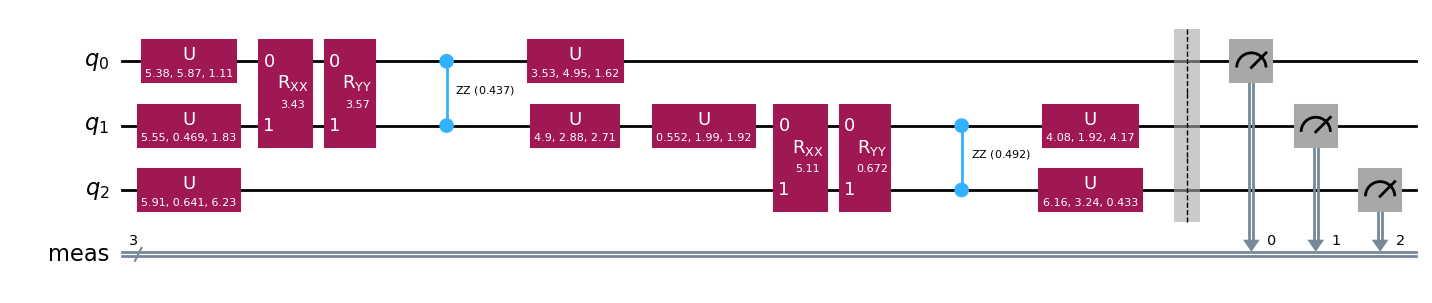

In [15]:
qc = U_hidden.copy()
qc2 = qiskit.QuantumCircuit(num_qubits)

circ = qc.compose(qc2)
circ.measure_all()
circ.draw(output="mpl")

In [32]:
result = backend.run(circ, shots=100).result()
result.data()

{'counts': {'0x1': 21,
  '0x6': 2,
  '0x5': 26,
  '0x2': 6,
  '0x0': 12,
  '0x4': 15,
  '0x7': 1,
  '0x3': 17}}